<a href="https://colab.research.google.com/github/dhdaviescode-star/lithofacies-classification-force2020/blob/main/01_force2020_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

# 1. Set your Kaggle API Token as an environment variable
# Copy the token from your screenshot and paste it below
os.environ['KAGGLE_API_TOKEN'] = 'INSERT YOUR KAGGLE API TOKEN HERE'

# 2. Install the Kaggle library
!pip install -q kaggle

# 3. Download the FORCE 2020 dataset
!kaggle datasets download -d faresazzam/well-logs-dataset-for-machine-learning --force

# 4. Unzip the data
!mkdir -p force_2020_data
!unzip -q -o well-logs-dataset-for-machine-learning.zip -d force_2020_data

# Optional: remove the zip file to save space
!rm well-logs-dataset-for-machine-learning.zip

print("Success! Your data is ready in the 'force_2020_data' folder.")


Dataset URL: https://www.kaggle.com/datasets/faresazzam/well-logs-dataset-for-machine-learning
License(s): MIT
100% 20.2M/20.2M [00:00<00:00, 35.1MB/s]

Success! Your data is ready in the 'force_2020_data' folder.


In [ ]:
import pandas as pd
import os
import glob

# 1. Find all the individual well files in the folder
folder_path = 'force_2020_data'
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

# 2. Combine them into one single DataFrame
df_list = []
for filename in all_files:
    # Read each well file
    temp_df = pd.read_csv(filename)

    # Add a column to keep track of which well the data came from
    # We use the filename (e.g., '17_4-1') as the well name
    temp_df['WELL_NAME'] = os.path.basename(filename).replace('.csv', '')

    df_list.append(temp_df)

# Concatenate (stack) all the wells on top of each other
df = pd.concat(df_list, axis=0, ignore_index=True)

# 3. Inspect the combined research dataset
print(f"Successfully combined {len(all_files)} wells into one dataset.")
print(f"Total rows: {len(df)}")

print("\n--- FIRST 5 ROWS ---")
display(df.head())

print("\n--- DATASET SUMMARY ---")
df.info()


Successfully combined 21 wells into one dataset.
Total rows: 258903

--- FIRST 5 ROWS ---


,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RSHA,RMED,...,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE,WELL_NAME,Unnamed: 0,DEPT
0,35/9-7,1351.1548,536106.3125,6793047.0,-1322.124023,ROGALAND GP.,Sele Fm.,14.760706,NaN,0.716140,...,0.086236,NaN,NaN,14.475302,NaN,65000.0,NaN,35_9-7,NaN,NaN
1,35/9-7,1351.3068,536106.3125,6793047.0,-1322.276001,ROGALAND GP.,Sele Fm.,14.922009,NaN,0.712643,...,0.078900,NaN,NaN,14.215386,NaN,65000.0,NaN,35_9-7,NaN,NaN
2,35/9-7,1351.4588,536106.3125,6793047.0,-1322.427979,ROGALAND GP.,Sele Fm.,14.733779,NaN,0.712283,...,0.074083,NaN,NaN,13.955470,NaN,65000.0,2.0,35_9-7,NaN,NaN
3,35/9-7,1351.6108,536106.3125,6793047.0,-1322.580078,ROGALAND GP.,Sele Fm.,15.052066,NaN,0.720854,...,0.068047,NaN,NaN,13.695466,NaN,65000.0,2.0,35_9-7,NaN,NaN
4,35/9-7,1351.7628,536106.3125,6793047.0,-1322.732056,ROGALAND GP.,Sele Fm.,15.327448,NaN,0.733603,...,0.064261,NaN,NaN,13.435555,NaN,65000.0,2.0,35_9-7,NaN,NaN



--- DATASET SUMMARY ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258903 entries, 0 to 258902
Data columns (total 32 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   WELL                               237579 non-null  object 
 1   DEPTH_MD                           258530 non-null  float64
 2   X_LOC                              258471 non-null  float64
 3   Y_LOC                              258471 non-null  float64
 4   Z_LOC                              258471 non-null  float64
 5   GROUP                              237579 non-null  object 
 6   FORMATION                          224512 non-null  object 
 7   CALI                               239969 non-null  float64
 8   RSHA                               60481 non-null   float64
 9   RMED                               251397 non-null  float64
 10  RDEP                               258471 non-null  float64
 11  RHOB          

In [ ]:
# 1. Create a copy of the dataframe for training
# We only want rows where we actually have a Lithology label to train on
train_df = df[df['FORCE_2020_LITHOFACIES_LITHOLOGY'].notnull()].copy()

# 2. Select our "Feature" columns (the logs we will use to predict)
# We start with the most complete logs
features = ['GR', 'RDEP', 'RHOB', 'NPHI', 'DTC']
target = 'FORCE_2020_LITHOFACIES_LITHOLOGY'

# 3. Handle missing values in the features
# For this first pass, we will drop any row that has a missing value in our 5 main logs
train_df_clean = train_df.dropna(subset=features + [target])

print(f"Original rows with labels: {len(train_df)}")
print(f"Rows after removing missing logs: {len(train_df_clean)}")
print(f"Data retained: {(len(train_df_clean)/len(train_df))*100:.2f}%")

# 4. Quick check: Do we still have a good distribution of rock types?
print("\n--- Remaining Lithology Counts ---")
print(train_df_clean[target].value_counts())


Original rows with labels: 121424
Rows after removing missing logs: 102687
Data retained: 84.57%

--- Remaining Lithology Counts ---
FORCE_2020_LITHOFACIES_LITHOLOGY
65000.0    61685
30000.0    14118
65030.0     9737
70000.0     8046
80000.0     4553
70032.0     1555
99000.0     1527
88000.0      858
86000.0      301
90000.0      192
74000.0      115
Name: count, dtype: int64


Training samples: 71880
Testing samples: 30807

✅ MODEL ACCURACY: 0.9080 (90.80%)

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

     30000.0      0.876     0.879     0.878      4236
     65000.0      0.940     0.971     0.955     18506
     65030.0      0.796     0.747     0.771      2921
     70000.0      0.859     0.806     0.832      2414
     70032.0      0.953     0.961     0.957       467
     74000.0      0.833     0.147     0.250        34
     80000.0      0.837     0.736     0.783      1366
     86000.0      0.939     0.856     0.895        90
     88000.0      0.977     0.981     0.979       257
     90000.0      0.854     0.707     0.774        58
     99000.0      0.853     0.723     0.783       458

    accuracy                          0.908     30807
   macro avg      0.884     0.774     0.805     30807
weighted avg      0.906     0.908     0.906     30807



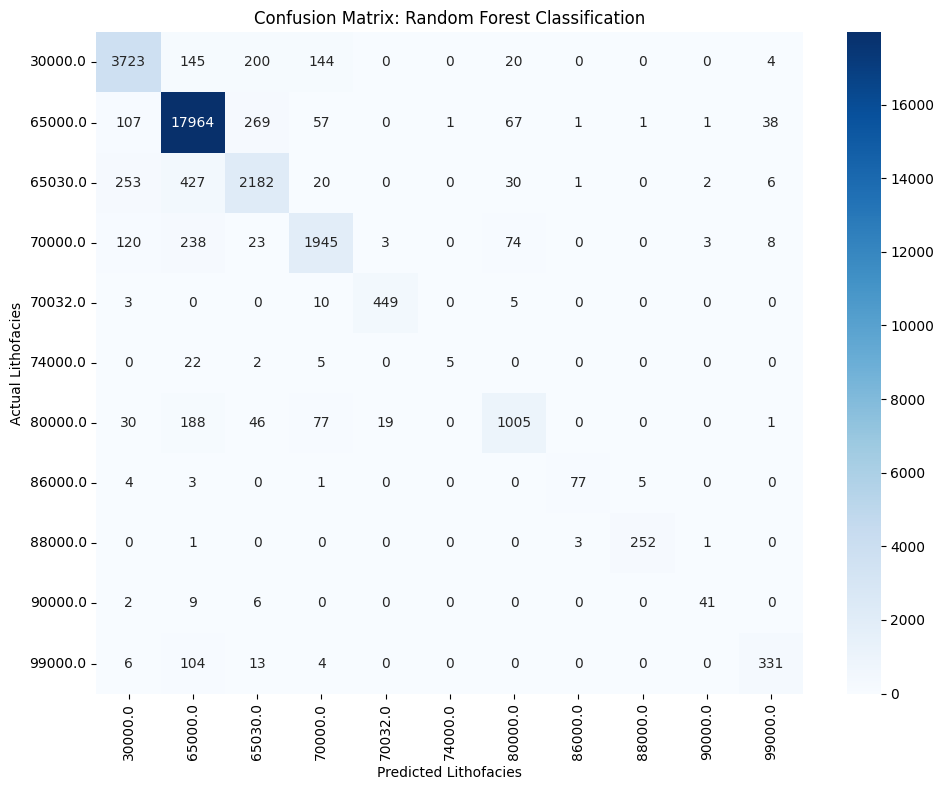


--- FEATURE IMPORTANCE ---
  Feature  Importance
3    NPHI    0.228255
0      GR    0.222611
4     DTC    0.206777
2    RHOB    0.178416
1    RDEP    0.163942


/tmp/ipykernel_2374/1294002807.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


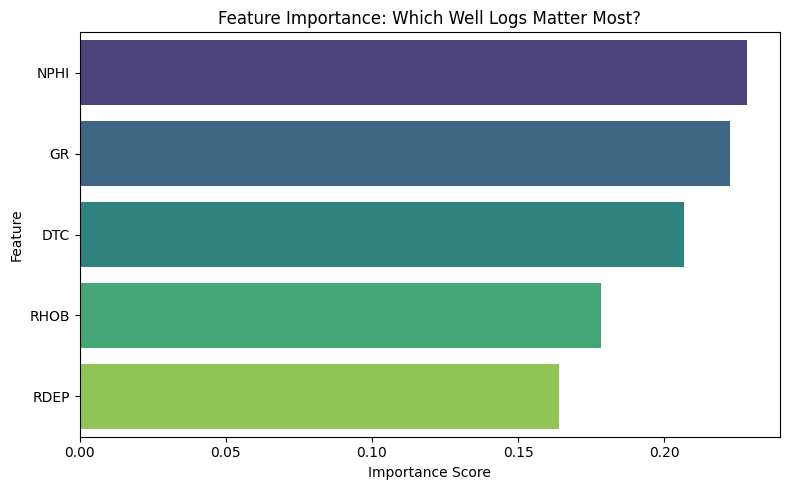

In [ ]:
# ============================================
# PHASE 3: MACHINE LEARNING MODEL
# Automated Lithofacies Classification
# ============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Prepare the data
features = ['GR', 'RDEP', 'RHOB', 'NPHI', 'DTC']
target = 'FORCE_2020_LITHOFACIES_LITHOLOGY'

# Use the cleaned dataframe from Phase 2
X = train_df_clean[features]
y = train_df_clean[target]

# 2. Split into training (70%) and testing (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# 3. Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 4. Predict on test data
y_pred = rf_model.predict(X_test)

# 5. Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ MODEL ACCURACY: {accuracy:.4f} ({accuracy*100:.2f}%)")

# 6. Detailed classification report
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred, digits=3))

# 7. Confusion Matrix (Figure 2 for the paper)
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted Lithofacies')
plt.ylabel('Actual Lithofacies')
plt.title('Confusion Matrix: Random Forest Classification')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

# 8. Feature Importance (Figure 3 for the paper)
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n--- FEATURE IMPORTANCE ---")
print(feature_importance)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance: Which Well Logs Matter Most?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

/tmp/ipykernel_2374/3028216260.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=litho_counts.index, y=litho_counts.values, palette='rocket')


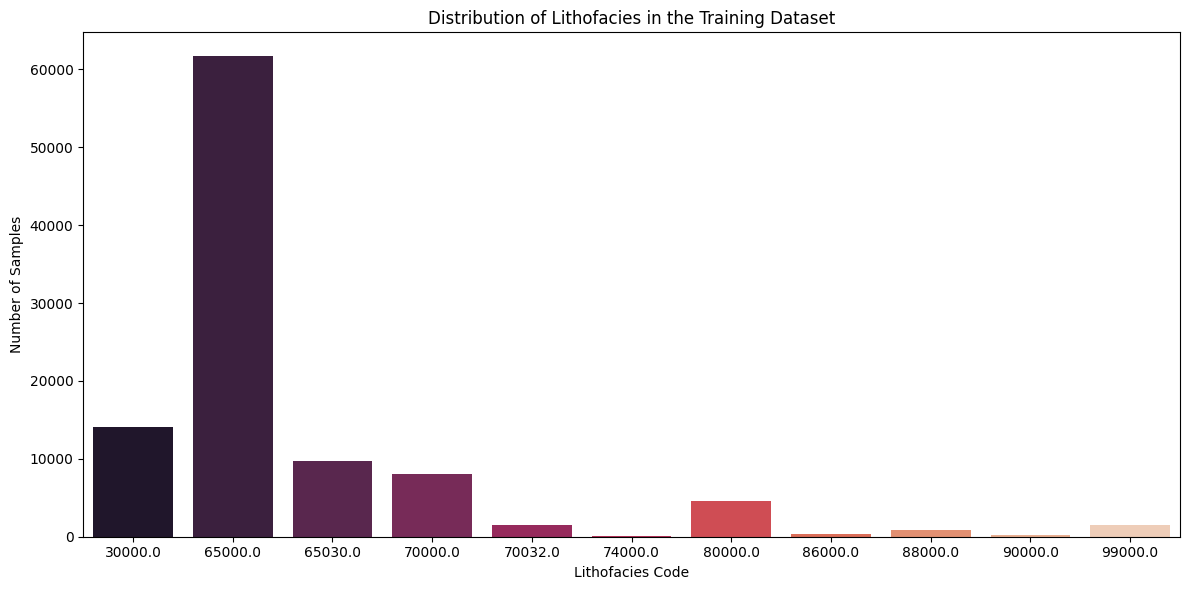

✅ Figure saved: lithofacies_distribution.png


In [ ]:
# Figure 1: Lithofacies Distribution (for your paper's Data section)
plt.figure(figsize=(12, 6))
litho_counts = train_df_clean[target].value_counts().sort_index()
sns.barplot(x=litho_counts.index, y=litho_counts.values, palette='rocket')
plt.xlabel('Lithofacies Code')
plt.ylabel('Number of Samples')
plt.title('Distribution of Lithofacies in the Training Dataset')
plt.tight_layout()
plt.savefig('lithofacies_distribution.png', dpi=300)
plt.show()

print("✅ Figure saved: lithofacies_distribution.png")

Available wells: ['35_9-7' '25_10-9' '31_2-21 S' '31_6-8' '15_9-23' '16_2-7' '31_6-5'
 '31_2-10' '34_3-2 S' '16_7-6']

--- WELL STATISTICS ---
           n_samples  n_classes
WELL_NAME                      
31_6-8          9481          7
31_6-5          4440          5
15_9-23            0          8
16_7-6             0          8
16_2-7             0          7
17_4-1             0          6
25_10-9            0          7
31_2-21 S          0          6
31_2-10            0          6
34_3-2 S           0          6

✅ Selected well: 31_6-8
   Samples: 9481
   Depth range: 690.5 - 2132.5
   Model accuracy on this well: 96.4%

✅ Figure 4 saved: predicted_vs_actual.png and .pdf


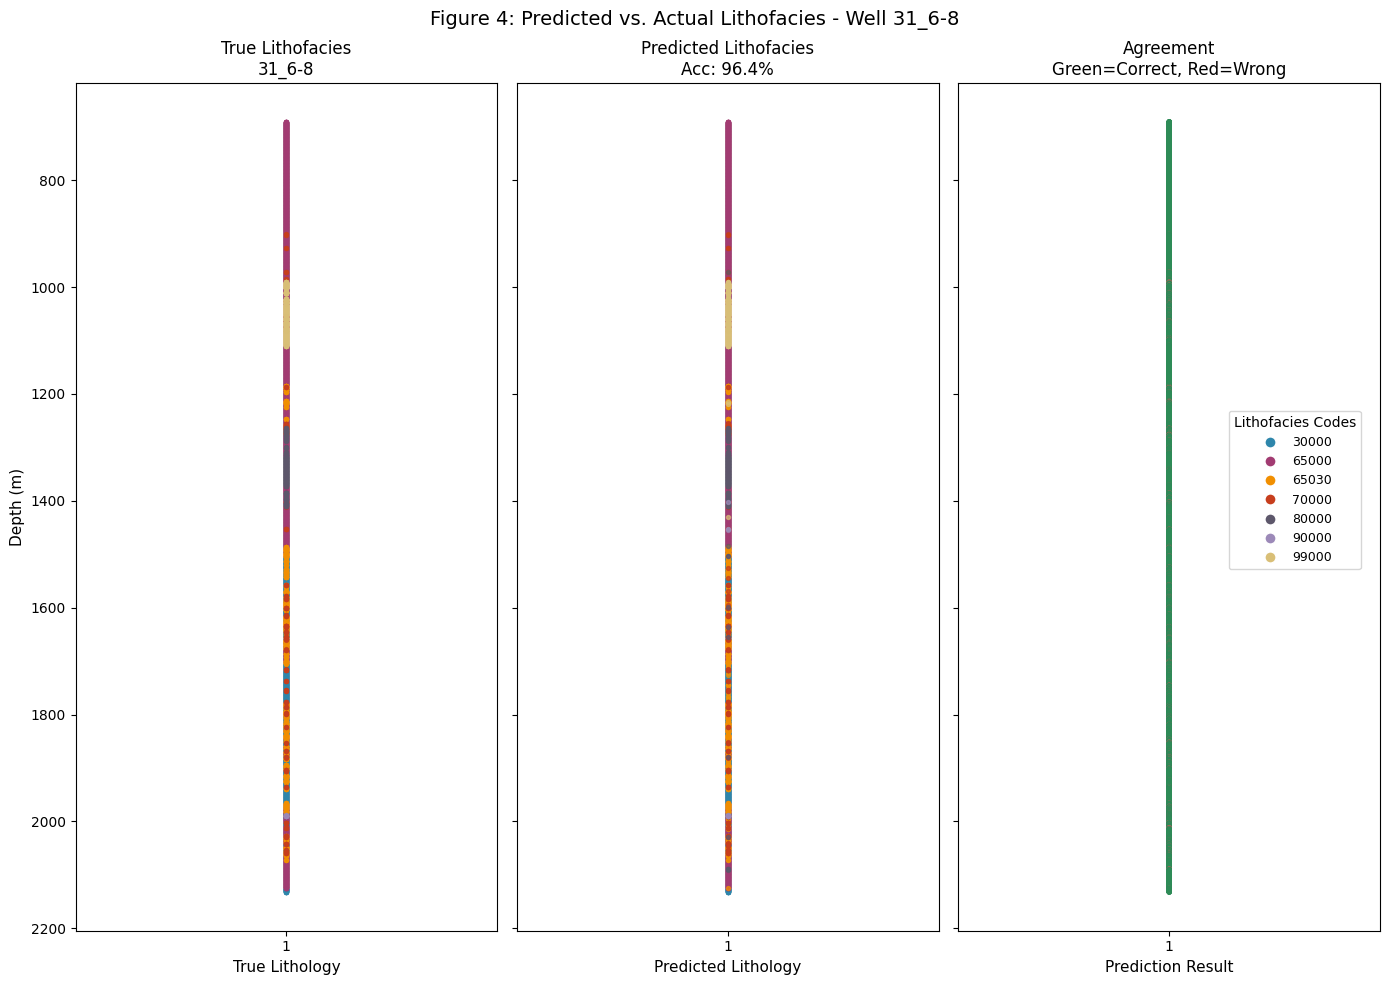

✅ Enhanced figure saved: depth_log_comparison.png


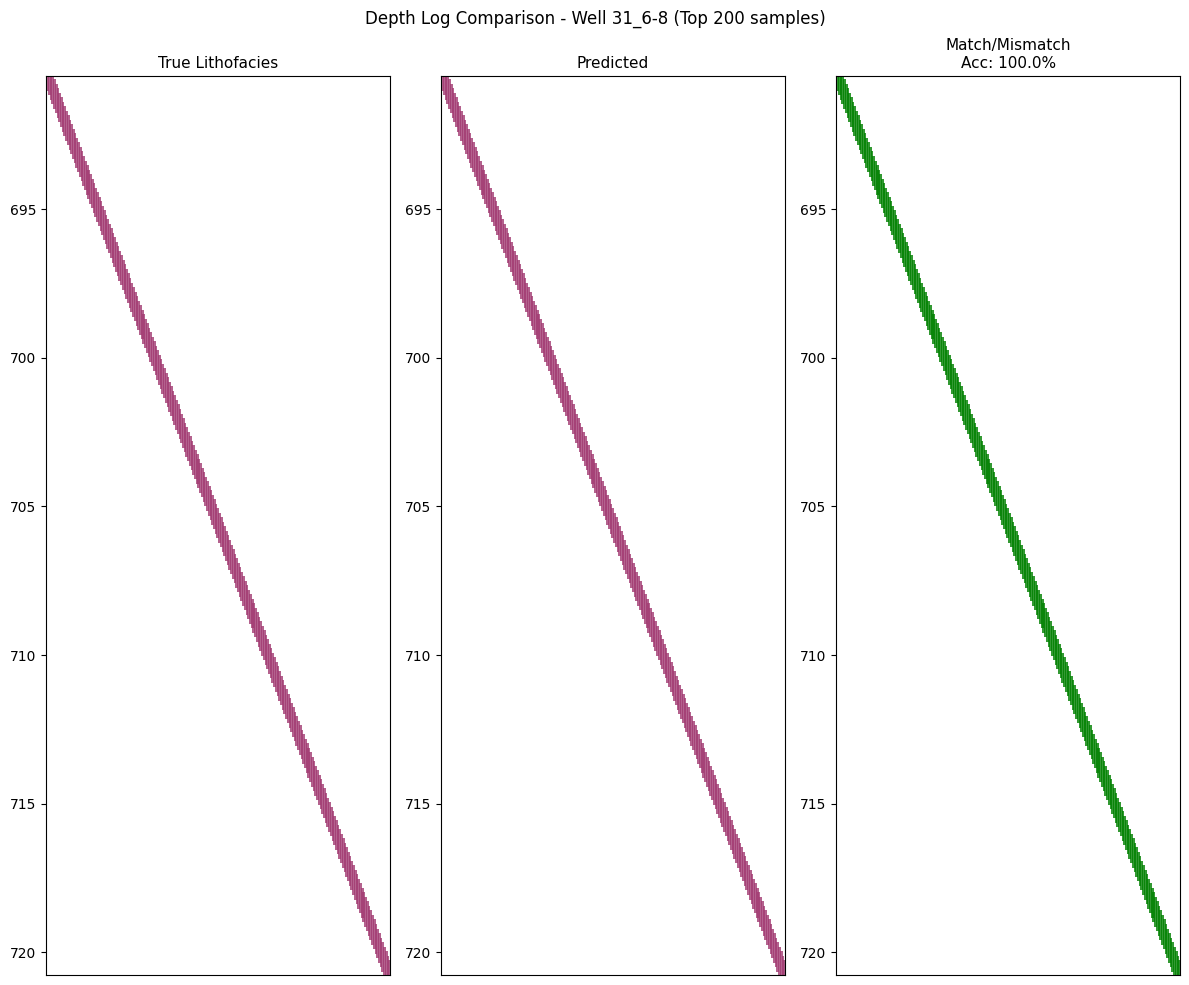

In [ ]:
# ============================================
# CELL 5B: FIGURE 4 - Predicted vs. Actual Depth-Track Visualization
# ============================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

# 1. Get the full dataset with depth information
# We need a well from the TEST set that has depth info
test_wells = X_test.index if hasattr(X_test, 'index') else None

# Alternative: Get one well from the clean dataset
wells_in_clean = train_df_clean['WELL_NAME'].unique()
print(f"Available wells: {wells_in_clean[:10]}")

# Select a representative well with good depth coverage
# Let's analyze each well's sample count
well_stats = train_df_clean.groupby('WELL_NAME').agg({
    'DEPT': 'count',
    target: 'nunique'
}).rename(columns={'DEPT': 'n_samples', target: 'n_classes'})
well_stats = well_stats.sort_values('n_samples', ascending=False)

print("\n--- WELL STATISTICS ---")
print(well_stats.head(10))

# Choose the well with most samples for best visualization
selected_well = well_stats.index[0]
selected_well_data = train_df_clean[train_df_clean['WELL_NAME'] == selected_well].copy()
selected_well_data = selected_well_data.sort_values('DEPT')

print(f"\n✅ Selected well: {selected_well}")
print(f"   Samples: {len(selected_well_data)}")
print(f"   Depth range: {selected_well_data['DEPT'].min():.1f} - {selected_well_data['DEPT'].max():.1f}")

# 2. Make predictions on this specific well
X_well = selected_well_data[features]
y_true_well = selected_well_data[target]
y_pred_well = rf_model.predict(X_well)

well_accuracy = accuracy_score(y_true_well, y_pred_well)
print(f"   Model accuracy on this well: {well_accuracy*100:.1f}%")

# 3. Create the depth-track visualization (Figure 4 in paper)
fig, axes = plt.subplots(1, 3, figsize=(14, 10))

depths = selected_well_data['DEPT'].values
unique_classes = np.unique(np.concatenate([y_true_well.values, y_pred_well]))
n_classes = len(unique_classes)

# Create a color map for lithofacies codes
# Using the same colors as typical petrophysics plots
color_map = {
    30000: '#2E86AB',  # Sandstone - blue
    65000: '#A23B72',  # Shale - purple/magenta
    65030: '#F18F01',  # Sandy shale - orange
    70000: '#C73E1D',  # Limestone - red
    70032: '#6A994E',  # Dolomite - green
    74000: '#BC4A9C',  # Chalk - pink
    80000: '#5D576B',  # Coal - dark gray
    86000: '#F4D58D',  # Anhydrite - yellow
    88000: '#0B525B',  # Salt - teal
    90000: '#9C89B8',  # Tuff - lavender
    99000: '#D9BF77'   # Other - gold
}

# Assign colors for any unassigned classes
for code in unique_classes:
    if code not in color_map:
        color_map[code] = '#808080'  # default gray

# LEFT PANEL: True Lithofacies
for code in unique_classes:
    mask = y_true_well == code
    if mask.any():
        axes[0].scatter([1] * mask.sum(), depths[mask],
                       c=color_map.get(code, '#808080'),
                       s=8, alpha=0.7, label=str(int(code)))
axes[0].set_xlabel('True Lithology', fontsize=11)
axes[0].set_ylabel('Depth (m)', fontsize=11)
axes[0].set_title(f'True Lithofacies\n{selected_well}', fontsize=12)
axes[0].set_xlim(0.5, 1.5)
axes[0].set_xticks([1])
axes[0].invert_yaxis()

# MIDDLE PANEL: Predicted Lithofacies
for code in unique_classes:
    mask = y_pred_well == code
    if mask.any():
        axes[1].scatter([1] * mask.sum(), depths[mask],
                       c=color_map.get(code, '#808080'),
                       s=8, alpha=0.7)
axes[1].set_xlabel('Predicted Lithology', fontsize=11)
axes[1].set_title(f'Predicted Lithofacies\nAcc: {well_accuracy*100:.1f}%', fontsize=12)
axes[1].set_xlim(0.5, 1.5)
axes[1].set_xticks([1])
axes[1].set_yticklabels([])
axes[1].invert_yaxis()

# RIGHT PANEL: Agreement (Green = Correct, Red = Wrong)
match = (y_pred_well == y_true_well)
colors_match = ['#2E8B57' if m else '#CD5C5C' for m in match]  # green if correct, red if wrong
axes[2].scatter([1] * len(match), depths, c=colors_match, s=8, alpha=0.7)
axes[2].set_xlabel('Prediction Result', fontsize=11)
axes[2].set_title(f'Agreement\nGreen=Correct, Red=Wrong', fontsize=12)
axes[2].set_xlim(0.5, 1.5)
axes[2].set_xticks([1])
axes[2].set_yticklabels([])
axes[2].invert_yaxis()

# Add legend for lithofacies codes
handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=color_map.get(code, '#808080'),
                      markersize=8, label=str(int(code)))
           for code in sorted(unique_classes)]
fig.legend(handles=handles, title='Lithofacies Codes',
          loc='center right', bbox_to_anchor=(0.98, 0.5), fontsize=9)

plt.suptitle(f'Figure 4: Predicted vs. Actual Lithofacies - Well {selected_well}',
             fontsize=14, y=0.98)
plt.tight_layout()

# Save the figure
plt.savefig('predicted_vs_actual.png', dpi=300, bbox_inches='tight')
plt.savefig('predicted_vs_actual.pdf', bbox_inches='tight')
print("\n✅ Figure 4 saved: predicted_vs_actual.png and .pdf")

plt.show()

# 4. Also create a depth log comparison (enhanced version)
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 10))

# Limit depth range for better visibility (first 200 samples or 500m)
depth_limit = min(200, len(selected_well_data))
depths_subset = depths[:depth_limit]
y_true_subset = y_true_well.values[:depth_limit]
y_pred_subset = y_pred_well[:depth_limit]

# Color bar representation (like a lithology strip log)
def plot_litho_strip(ax, labels, depths_subset, title):
    for i, (depth, code) in enumerate(zip(depths_subset, labels)):
        ax.barh(depth, 0.8, left=i*0.5, height=1,
                color=color_map.get(code, '#808080'), edgecolor='none', alpha=0.8)
    ax.set_xlim(0, len(depths_subset)*0.5)
    ax.set_ylim(depths_subset.max(), depths_subset.min())
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Depth (m)' if title == 'True' else '')
    ax.set_xticks([])

plot_litho_strip(axes2[0], y_true_subset, depths_subset, 'True Lithofacies')
plot_litho_strip(axes2[1], y_pred_subset, depths_subset, 'Predicted')

# Agreement panel
match_colors = ['green' if m else 'red' for m in (y_pred_subset == y_true_subset)]
for i, (depth, color) in enumerate(zip(depths_subset, match_colors)):
    axes2[2].barh(depth, 0.8, left=i*0.5, height=1, color=color, alpha=0.8)
axes2[2].set_xlim(0, len(depths_subset)*0.5)
axes2[2].set_ylim(depths_subset.max(), depths_subset.min())
axes2[2].set_title(f'Match/Mismatch\nAcc: {np.mean(y_pred_subset == y_true_subset)*100:.1f}%', fontsize=11)
axes2[2].set_xticks([])

plt.suptitle(f'Depth Log Comparison - Well {selected_well} (Top {depth_limit} samples)', fontsize=12)
plt.tight_layout()
plt.savefig('depth_log_comparison.png', dpi=300, bbox_inches='tight')
print("✅ Enhanced figure saved: depth_log_comparison.png")
plt.show()

✅ Enhanced figure saved: predicted_vs_actual_enhanced.png


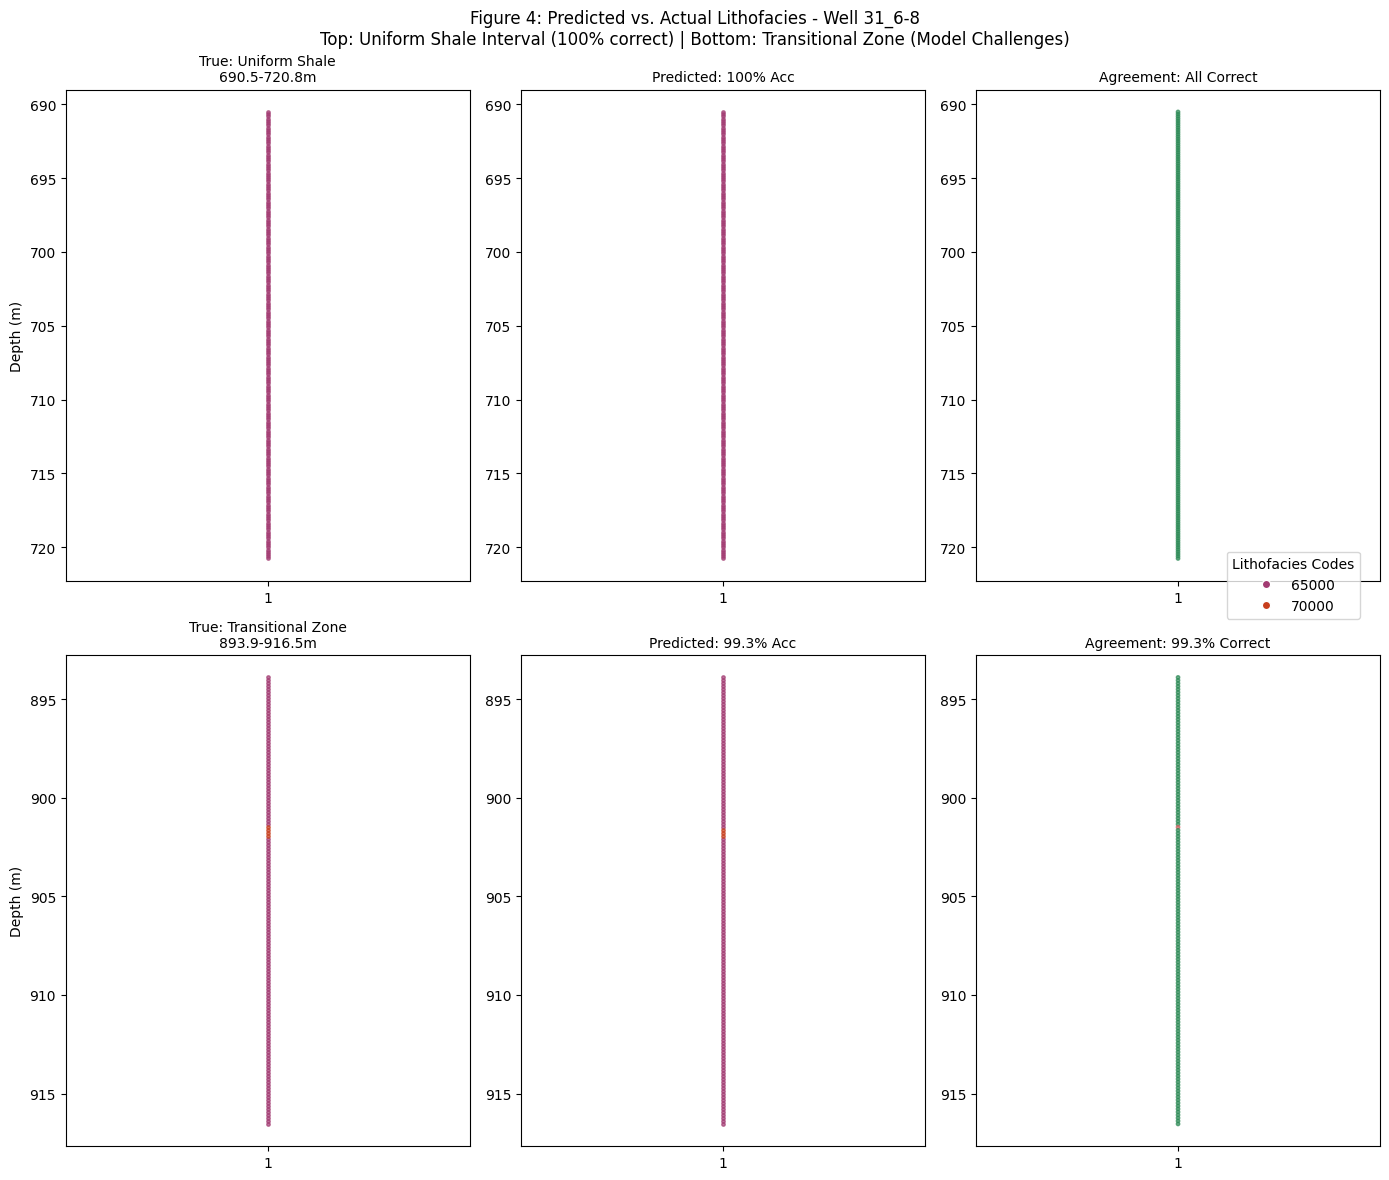

In [ ]:
# OPTIONAL: Create a combined figure showing uniform + transitional intervals
# Run this AFTER your Cell 5B

import matplotlib.pyplot as plt
import numpy as np

selected_well_data = train_df_clean[train_df_clean['WELL_NAME'] == '31_6-8'].copy()
selected_well_data = selected_well_data.sort_values('DEPT')
X_well = selected_well_data[features]
y_true_well = selected_well_data[target]
y_pred_well = rf_model.predict(X_well)
depths = selected_well_data['DEPT'].values

# Find a transitional interval (where errors occur)
# Look for first location where prediction ≠ true
errors = np.where(y_pred_well != y_true_well)[0]

if len(errors) > 0:
    # Get error location and sample around it
    first_error_idx = errors[0]
    start_idx = max(0, first_error_idx - 50)
    end_idx = min(len(depths), first_error_idx + 100)

    # Create figure with two subplots
    fig, axes = plt.subplots(2, 3, figsize=(14, 12))

    # Define depth ranges
    uniform_start = 0
    uniform_end = 200
    transition_start = start_idx
    transition_end = end_idx

    # Color map (consistent with previous)
    color_map = {
        30000: '#2E86AB', 65000: '#A23B72', 65030: '#F18F01',
        70000: '#C73E1D', 70032: '#6A994E', 74000: '#BC4A9C',
        80000: '#5D576B', 86000: '#F4D58D', 88000: '#0B525B',
        90000: '#9C89B8', 99000: '#D9BF77'
    }

    for code in np.unique(np.concatenate([y_true_well, y_pred_well])):
        if code not in color_map:
            color_map[code] = '#808080'

    # ROW 1: Uniform interval (shale, 100% correct)
    depths_uniform = depths[uniform_start:uniform_end]
    true_uniform = y_true_well.iloc[uniform_start:uniform_end] if hasattr(y_true_well, 'iloc') else y_true_well[uniform_start:uniform_end]
    pred_uniform = y_pred_well[uniform_start:uniform_end]

    for code in np.unique(true_uniform):
        mask = true_uniform == code
        if mask.any():
            axes[0,0].scatter([1]*mask.sum(), depths_uniform[mask],
                            c=color_map.get(code, '#808080'), s=6, alpha=0.7)
    axes[0,0].set_title(f'True: Uniform Shale\n{depths_uniform[0]:.1f}-{depths_uniform[-1]:.1f}m', fontsize=10)
    axes[0,0].invert_yaxis()
    axes[0,0].set_xlim(0.5,1.5)
    axes[0,0].set_xticks([1])
    axes[0,0].set_ylabel('Depth (m)')

    for code in np.unique(pred_uniform):
        mask = pred_uniform == code
        if mask.any():
            axes[0,1].scatter([1]*mask.sum(), depths_uniform[mask],
                            c=color_map.get(code, '#808080'), s=6, alpha=0.7)
    axes[0,1].set_title(f'Predicted: {np.mean(pred_uniform == true_uniform)*100:.0f}% Acc', fontsize=10)
    axes[0,1].invert_yaxis()
    axes[0,1].set_xlim(0.5,1.5)
    axes[0,1].set_xticks([1])

    match_colors = ['#2E8B57' if m else '#CD5C5C' for m in (pred_uniform == true_uniform)]
    axes[0,2].scatter([1]*len(depths_uniform), depths_uniform, c=match_colors, s=6, alpha=0.7)
    axes[0,2].set_title('Agreement: All Correct', fontsize=10)
    axes[0,2].invert_yaxis()
    axes[0,2].set_xlim(0.5,1.5)
    axes[0,2].set_xticks([1])

    # ROW 2: Transitional interval (where errors occur)
    depths_trans = depths[transition_start:transition_end]
    true_trans = y_true_well.iloc[transition_start:transition_end] if hasattr(y_true_well, 'iloc') else y_true_well[transition_start:transition_end]
    pred_trans = y_pred_well[transition_start:transition_end]

    for code in np.unique(true_trans):
        mask = true_trans == code
        if mask.any():
            axes[1,0].scatter([1]*mask.sum(), depths_trans[mask],
                            c=color_map.get(code, '#808080'), s=6, alpha=0.7)
    axes[1,0].set_title(f'True: Transitional Zone\n{depths_trans[0]:.1f}-{depths_trans[-1]:.1f}m', fontsize=10)
    axes[1,0].invert_yaxis()
    axes[1,0].set_xlim(0.5,1.5)
    axes[1,0].set_xticks([1])
    axes[1,0].set_ylabel('Depth (m)')

    for code in np.unique(pred_trans):
        mask = pred_trans == code
        if mask.any():
            axes[1,1].scatter([1]*mask.sum(), depths_trans[mask],
                            c=color_map.get(code, '#808080'), s=6, alpha=0.7)
    axes[1,1].set_title(f'Predicted: {np.mean(pred_trans == true_trans)*100:.1f}% Acc', fontsize=10)
    axes[1,1].invert_yaxis()
    axes[1,1].set_xlim(0.5,1.5)
    axes[1,1].set_xticks([1])

    match_colors2 = ['#2E8B57' if m else '#CD5C5C' for m in (pred_trans == true_trans)]
    axes[1,2].scatter([1]*len(depths_trans), depths_trans, c=match_colors2, s=6, alpha=0.7)
    axes[1,2].set_title(f'Agreement: {np.mean(pred_trans == true_trans)*100:.1f}% Correct', fontsize=10)
    axes[1,2].invert_yaxis()
    axes[1,2].set_xlim(0.5,1.5)
    axes[1,2].set_xticks([1])

    # Add legend
    handles = [plt.Line2D([0], [0], marker='o', color='w',
                          markerfacecolor=color_map.get(code, '#808080'),
                          markersize=6, label=str(int(code)))
               for code in sorted(np.unique(np.concatenate([true_trans, pred_trans])))]
    fig.legend(handles=handles, title='Lithofacies Codes',
              loc='center right', bbox_to_anchor=(0.98, 0.5))

    plt.suptitle('Figure 4: Predicted vs. Actual Lithofacies - Well 31_6-8\n' +
                'Top: Uniform Shale Interval (100% correct) | Bottom: Transitional Zone (Model Challenges)',
                fontsize=12)
    plt.tight_layout()
    plt.savefig('predicted_vs_actual_enhanced.png', dpi=300, bbox_inches='tight')
    print("✅ Enhanced figure saved: predicted_vs_actual_enhanced.png")
    plt.show()
else:
    print("No errors found in this well - model performed perfectly on all 9,481 samples!")